In [30]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [31]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [32]:
y = df['tip']
x = df.drop('tip',axis=1)

In [33]:
df.info()



<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [34]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [35]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

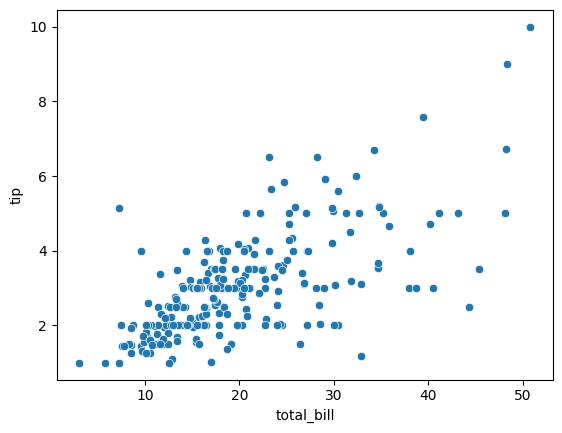

In [36]:
sns.scatterplot(x='total_bill',y='tip', data=df)
plt.show()

<Axes: >

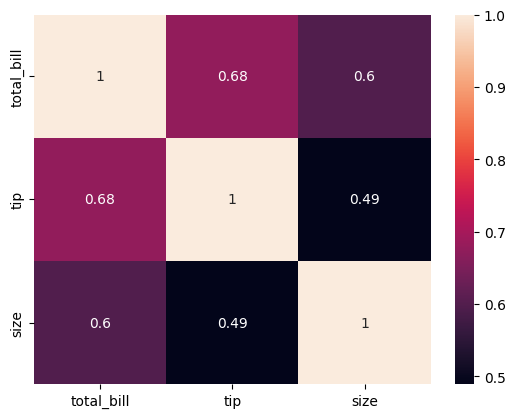

In [37]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [38]:
cat_cols =['sex','smoker','day','time']
num_cols =['total_bill','size']

In [39]:
features=['total_bill','size','sex','smoker','day','time']
x= df[features]

In [40]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42)

In [41]:
preprocessor = ColumnTransformer([
    ('cat',OneHotEncoder(drop='first'), cat_cols),
    ('num', StandardScaler (), num_cols)
])

pipeline=Pipeline([
    ('preprocessor','preprocessor'),
    ('model',LinearRegression())
])

In [42]:
pipeline.fit(x_train, y_train)

TypeError: All intermediate steps should be transformers and implement fit and transform or be the string 'passthrough' 'preprocessor' (type <class 'str'>) doesn't